# Линейная алгебра. Лабораторная работа 1, осень 2025



В этой лабораторной работе вы познакомитесь со средой Jupyter Notebook и библиотеками numpy и scipy.

## Часть 1. Библиотеки

В этой лабораторной работе вам понадобятся три библиотеки:

- `numpy` – основная библиотека для работы с матрицами;
- `scipy`, а точнее модуль `scipy.linalg`, содержащий множество функций линейной алгебры;
- `matplotlib` – графическая библиотека

Подключить их можно следующим образом:

In [1]:
# Запустите этот код
import numpy as np

import scipy.linalg as sla

import matplotlib.pyplot as plt
%matplotlib inline

Теперь вы можете позвать, скажем, функцию `scipy.linalg.det()` с помощью кода `sla.det()`, а функцию `numpy.exp()` – с помощью кода `np.exp()`.

**Основные объекты и операции линейной алгебры в NumPy и SciPy:**

Основной объект, с которым вам придётся работать и в этой, и в следующих лабораторных, – это, безусловно, матрицы. В библиотеке `numpy` они представлены классом `numpy.ndarray`. Матрицу можно создать из двумерного (а на самом деле и не только двумерного) массива следующим образом:

In [2]:
# Запустите этот код
A = np.array([[1, 2, 3], [4, 5, 6]])

print(A)
print(A.shape) # пара (число строк, число столбцов)

[[1 2 3]
 [4 5 6]]
(2, 3)


Обратите внимание, что матрица заполняется *по строкам*.

Есть и много других конструкторов матриц. Например, единичная матрица размера $n\times n$ создаётся с помощью функции `numpy.eye(n)`. Со всем многообразием конструкторов можно ознакомиться [на этой странице](https://docs.scipy.org/doc/numpy-1.10.1/reference/routines.array-creation.html).

Зачастую бывает нужно получить доступ к подматрицам данной матрицы, и numpy предоставляет множество удобных средств, как это сделать (вообще данная процедура называется slicing):
- элемент с номером `(i,j)`: `A[i,j]`
- i-я строка матрицы: `A[i,:]`
- j-й столбец матрицы: `A[:,j]`

**Внимание!** Оба варианта, и `A[i,:]`, и `A[:,j]` дают не строку или столбец, а одномерный вектор. Если вы хотите получить вектор-строку или вектор-столбец соответственно, используйте вот такой синтаксис: `A[i:i+1,:]` и `A[:,j:j+1]`
- строки с нулевой по i-ю: `A[:i+1,:]`
- столбцы с j-го по последний: `A[:,j:]`
- строки с i-й по k-ю: `A[i:k+1,:]`

В некоторых случаях нужно получить доступ к (прямоугольной) подматрице, элементы которой находятся на пересечении строк из списка `rows` и столбцов из списка `columns`. В этом случае `A[rows, columns]` даст не то, что вы ожидаете (можете попробовать это сделать сами и увидеть, что получится; только возьмите `rows` и `columns` одного размера). Справиться с этой задачей позволяет код `A[np.ix_(rows, columns)]`

*Умножение матриц* производится с помощью функции `np.dot()` либо оператора `@`. Есть три варианта написания: `A.dot(B)`, `np.dot(A, B)` и `A @ B`.

Обычные знаки арифметических действий (`+`, `-`, `*`) зарезервированы для поэлементных операций. Например, `A * B` – это матрица, элементами которой являются произведения $a_{ij}b_{ij}$. Помимо этих есть и множество других поэлементных операций. Например, `numpy.exp(A)` – это матрица, элементами которой являются экспоненты элементов матрицы `A`.

Чтобы получить матрицу, *транспонированную* к матрице `A`, напишите просто `A.T`.

В некоторых случаях бывает нужно создавать *случайные матрицы*: например, при проведении экспериментов или для инициализации итеративных методов. Средства для этого предоставляет пакет [numpy.random](https://docs.scipy.org/doc/numpy/reference/routines.random.html). Так, `np.random.rand(m,n)` – это матрица $m\times n$, элементы которой независимо выбраны из равномерного распределения на интервале `[0;1)`.

Для *решения систем линейных уравнений* в пакете `scipy.linalg` есть множество методов, рассмотрение которых выходит за пределы стандартного курса линейной алгебры. Мы вам пока предлагаем пользоваться функцией `scipy.linalg.solve`, основанной на методе Гаусса. Отметим, что `scipy.linalg.solve(A, B)` выдаёт решение уравнения $AX = B$ (или ошибку), где $B$ может быть как вектором, так и матрицей.

Найти обратную матрицу для матрицы $A$ можно с помощью функции `sla.inv(A)`.

**Копирование сложных объектов в Python**

Когда вы делаете присваивание каких-то сложных объектов, как правило, оно происходит по ссылке. Например, код
```
B = A
B[0,0] = 10
```
приведёт к изменению матрицы `A`.

Не попадайтесь в эту ловушку! Если вы хотите работать с копией как с независимой матрицей, используйте метод `copy()`:
```
B = A.copy()
```

**Где искать помощь**

Библиотеки `numpy` и `scipy` снабжены прекрасной документацией. Если у вас возникают вопросы о том, как работает та или иная функция (или даже как называется функция, выполняющая то, что вам нужно), вы почти всегда можете найти там ответы.

[Ссылка на документацию пакета scipy.linalg](https://docs.scipy.org/doc/scipy-0.18.1/reference/linalg.html)

Если у вас возникает какая-то ошибка и вы не можете понять, что вы делаете не так, то

1) в первую очередь попробуйте просто загуглить текст ошибки, наверняка в интернете кто-то уже сталкивался с такой ситуацией;  
2) поспрашивайте своих одногруппников, не было ли у них такой ошибки, и если была, то как они справлялись;  
3) попросите помощи у вашего учебного ассистента.




**И всё-таки задание**

**Задание 1.1 [0.2 балла за каждый пункт]** В качестве первого задания мы попросим вас отыскать соответствующие функции в библиотеке и сделать следующее:

- создайте нулевую матрицу $Z$ размера $3\times4$;

- создайте диагональную матрицу $5\times5$ с диагональными элементами 1, 2, 3, 4 и 5;

- найдите её след (не силою мысли, а с помощью библиотечных функций, конечно);

- найдите обратную к ней матрицу;

- сгенерируйте случайную матрицу $X$ размера $4\times5$;

- найдите определитель подматрицы матрицы $X$, расположенной на пересечении 2-й и 3-й строк и 1-го и 2-го столбцов; считаем, что строки и столбцы нумеруются с единицы (используйте slicing!). Такой определитель называется **минором** матрицы $X$;

- найдите произведение $X^TX$.

Пожалуйста, каждый пункт делайте в новом блоке и не забывайте распечатывать результаты.

In [3]:
Z = np.zeros((3,4))
print(Z)

[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


In [4]:
D = np.diag((1,2,3,4,5))
print(D)

[[1 0 0 0 0]
 [0 2 0 0 0]
 [0 0 3 0 0]
 [0 0 0 4 0]
 [0 0 0 0 5]]


In [5]:
tr = D.trace()
print(tr)

15


In [6]:
F = sla.inv(D)
print(F)

[[ 1.          0.          0.          0.         -0.        ]
 [ 0.          0.5         0.          0.         -0.        ]
 [ 0.          0.          0.33333333  0.         -0.        ]
 [ 0.          0.          0.          0.25       -0.        ]
 [ 0.          0.          0.          0.          0.2       ]]


In [7]:
X = np.random.rand(4, 5)
print(X)

[[0.91612505 0.74542261 0.61170444 0.77796418 0.59883512]
 [0.89937614 0.85209232 0.24308133 0.82585646 0.73510833]
 [0.44987441 0.1625167  0.68529105 0.05860739 0.34919732]
 [0.0274034  0.52821605 0.18699168 0.64820248 0.44175488]]


In [8]:
M = X[1:3, 0:2]
det_M = sla.det(M)
print(det_M)

-0.23717088267100056


In [9]:
XT = X.T
print(XT @ X)

[[1.85130047 1.53683884 1.09243843 1.49959699 1.37894726]
 [1.53683884 1.58714005 0.87324931 1.63553367 1.36285781]
 [1.09243843 0.87324931 0.93786057 0.83800603 0.8669075 ]
 [1.49959699 1.63553367 0.83800603 1.71086845 1.37977839]
 [1.37894726 1.36285781 0.8669075  1.37977839 1.21607389]]


## Часть 2. Время

Питон мотивирует пользоваться библиотечными функциями, когда они доступны, а не писать собственные. Библиотечные функции основаны на современных алгоритмах, обычно пишутся на более эффективных языках, таких как C++ или Fortran, а кроме того, оптимизированы для работы на многопроцессорных устройствах, так что обогнать эти решения просто так вы не сможете.

**Задание 2.1 [1 балл]**
Мы предлагаем вам убедиться в этом самим. Напишите функцию `my_det`, которая вычисляла бы определитель матрицы с помощью элементарных преобразований над строками. Функция должна выкидывать `ValueError` в случаях, если матрица не является квадратной.

In [10]:
def my_det(X):
    '''
    Parameters
    ----------
    X : array_like

    Returns
    -------
    det : float
        Determinant of `a`.
    '''

    X = np.array(X, dtype=float)
    n = X.shape[0]
    if X.shape[0] != X.shape[1]:
        raise ValueError

    A = X.copy()
    log_abs_det = 0.0
    sign = 1

    for i in range(n):
        pivot = i + np.argmax(np.abs(A[i:, i]))
        if np.isclose(A[pivot, i], 0):
            return 0.0
        if pivot != i: 
            A[[i, pivot]] = A[[pivot, i]] 
            sign *= -1
        sign *= np.sign(A[i, i]) 
        log_abs_det += np.log(np.abs(A[i, i])) 
        A[i] /= A[i, i] 
        for j in range(i+1, n): 
            A[j] -= A[i] * A[j, i]

    if abs(log_abs_det) > 700:
        return (sign, log_abs_det)
    else:
        return sign * np.exp(log_abs_det)
    

    # В написанном выше коде я вычисляю логарифмический детерминант и потом, 
    # если это безопасно, то перевожу его в обычное число. 
    # Как я понял, у числа с плавающей точкой есть ограничение, 
    # и для больших матриц, когда ниже в бенчмарке строятся графики, 
    # вылетает ошибка переполнения числа. Единственный способ, 
    # который я придумал - выводит знак и логарифмический детерминант, 
    # если число слишком большое, иначе можно сделать обычный вывод.

Простая проверка:

In [11]:
# Запустите этот блок кода
X = np.array([[0,0,1], [0,1,0], [1,0,0]])
print(my_det(X))

-1.0


На случай, если нам просто повезло с этой матрицей, имеет смысл написать чуть более хитрые тесты. Мы сгенерируем несколько случайных матриц $50\times50$ с помощью функции `numpy.random.rand` и сравним ответ, выдаваемый нашей функцией, с настоящим определителем (результатом работы библиотечной функции `scipy.linalg.det`):

In [12]:
# Запустите этот блок кода
for _ in range(50):
    X = np.random.rand(50, 50)
    if np.abs(my_det(X) - sla.det(X)) > 1e-6:
        print('FAILED')

Если вы ни разу не получили `FAILED`, то ваша функция работает правильно.

Теперь давайте сравним скорость работы вашей функции и библиотечной функции `scipy.linalg.det`. В Питоне есть несколько способов измерения времени; мы воспользуемся декоратором `%timeit`. Будучи написан перед функцией, он запускает её некоторое количество раз, выбирает три случайных запуска и возвращает длительность самого быстрого из них. Модификатор `-o` между декоратором и функцией позволяет сохранять результаты работы декоратора в переменную.

Приготовьтесь, что следующий блок может работать сравнительно долго.

3.04 µs ± 163 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
104 µs ± 1.13 µs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
39.3 µs ± 63.5 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
3.92 ms ± 18.4 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)
The slowest run took 8.52 times longer than the fastest. This could mean that an intermediate result is being cached.
17.8 ms ± 18.5 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)
464 ms ± 3.11 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


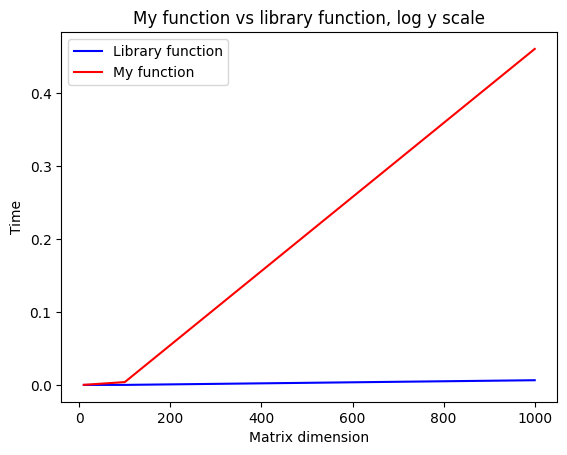

In [13]:
# Запустите этот блок кода
lib_times = []
my_times = []
dimensions = [10, 100, 1000]
for dim in dimensions:
    A = np.random.rand(dim, dim)
    res_lib = %timeit -o sla.det(A)
    lib_times.append(res_lib.best)
    res_my = %timeit -o my_det(A)
    my_times.append(res_my.best)

plt.plot(dimensions, lib_times, color='blue', label='Library function')
plt.plot(dimensions, my_times, color='red', label='My function')
plt.title('My function vs library function, log y scale')
plt.ylabel('Time')
plt.xlabel('Matrix dimension')
plt.legend()

У вас должны были получиться графики, показывающие, как растёт с ростом размерности матрицы время вычисления определителя. Поскольку они вышли не больно-то красивыми, мы нарисуем их в *логарифмическом масштабе* по оси у:

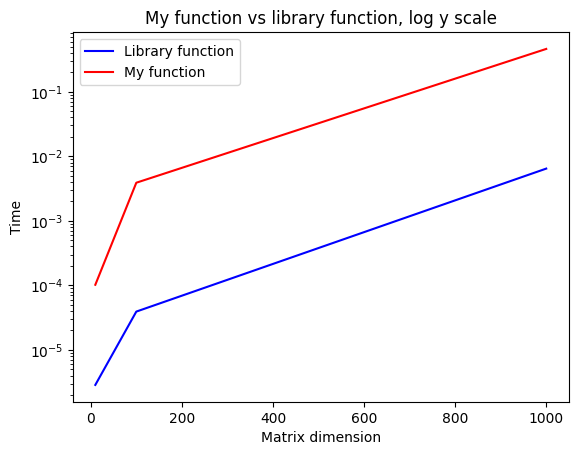

In [14]:
# Запустите этот блок кода
plt.semilogy(dimensions, lib_times, color='blue', label='Library function')
plt.semilogy(dimensions, my_times, color='red', label='My function')
plt.title('My function vs library function, log y scale')
plt.ylabel('Time')
plt.xlabel('Matrix dimension')
plt.legend()

Вы можете убедиться, что библиотечная функция работает *гораздо* быстрее.

## Часть 3. Точность

Наверняка вы уже что-то знаете про floating point arithmetics и связанные с этим трудности и понимаете, что на компьютере вычисления с вещественными числами производятся лишь с ограниченной точностью.

**Задание 3.1 [0.6 балла]** В качестве первого примера, показывающего различие между длинной арифметикой целых чисел и floating point arithmetics, предлагаем вам перемножить две пары матриц:

$$
\begin{pmatrix}
1 & 0\\
10^{20} & 1
\end{pmatrix}
\cdot
\begin{pmatrix}
10^{-20} & 1\\
0 & 1 - 10^{20}
\end{pmatrix}
$$
и
$$
\begin{pmatrix}
1. & 0.\\
10.^{20} & 1.
\end{pmatrix}
\cdot
\begin{pmatrix}
10.^{-20} & 1.\\
0. & 1. - 10.^{20}
\end{pmatrix}
$$
Во втором случае мы специально указали Питону (поставив везде десятичные точки), что хотим работать не с целыми числами, а с числами с плавающей точкой. Посмотрим, получатся ли одинаковые ответы:

In [15]:
A = np.array([[1, 0], [10**20, 1]])
B = np.array([[10**-20, 1], [0, 1 - 10**20]])
C = np.array([[1, 0], [10**20, 1]], dtype=float)
D = np.array([[10**-20, 1], [0, 1 - 10**20]], dtype=float)

print(A @ B)
print('-------------------------')
print(C @ D)

[[1e-20 1]
 [1.0 1]]
-------------------------
[[1.e-20 1.e+00]
 [1.e+00 0.e+00]]


И какой из них правильный?

---
Первый вариант правильный, т.к. при работе с float очень большие или маленькие числа округляются и теряется точность.

**Задание 3.2 [0.75 балла]** Впрочем, и с целыми числами тоже не всегда всё хорошо. Напишите функцию, генерирующую *матрицу Паскаля* заданной размерности $n$, то есть матрицу $P$, в которой $P_{ij} = C_{i+j}^i$. В этом задании нельзя пользоваться библиотечной функцией `scipy.linalg.pascal` или её аналогами из других библиотек. Обратите внимание, что использование факториалов крайне нежелательно, так как быстро приведёт к переполнению.

В этом задании вы можете использовать цикл ``for``.

In [16]:
def my_pascal(dim):
    '''
    Мы создали для вас матрицу из нулей размера dim x dim,
    но вы можете ей не пользоваться, если не хотите
    '''
    P = np.zeros((dim, dim))

    for i in range(dim):
        P[i, 0] = 1
    for j in range(dim):
        P[0, j] = 1
    
    for i in range(1, dim):
        for j in range(1, dim):
            P[i, j] = P[i - 1, j] + P[i, j - 1]

    return P


Чему равен её определитель? **Строго** поясните свой ответ.

----
$det(P) = 1$ 

По определению $P_{ij} = \frac{(i+j)!}{i!j!}$

Представим матрицу Паскаля как произведение мариц L и U, где

$L$ - нижнетреугольная матрица с элементами $L_{ij} = \binom{i}{j}$ (при $i \leq j$, иначе 0)

U - верхнетреугольная матрица с элементами $U_{ij} = \binom{j}{i}$ (при $i \leq j$, иначе 0)

Докажем, что P = LU:

Используем тождество Вандермонда: $\sum_k \binom{i}{k} \binom{j}{k} = \sum_k \binom{i}{k} \binom{j}{j-k} = \binom{i+j}{j} = \binom{i+j}{i}$

Отсюда строим тождество: $(LU)_{ij} = \sum^{n}_{k=1} \binom{i}{k} \binom{j}{k} = \binom{i + j}{i} = P_{ij}$

Теперь несложно посчитать определитель матрицы Паскаля, он равен произведению определителей матриц L и U. По построению это нижнетреугольные/верхнетреугольные матрицы с единицами на главной диагонали, т.к. $\binom{i}{i} = 1$. Определитель таких матриц - произведение элементов главной диагонали, то есть 1. Отсюда определитель матрицы Паскаля равен 1.

А теперь вычислите определитель матрицы Паскаля $30\times30$ с помощью библиотечной функции `scipy.linalg.det`:

In [17]:
print(sla.det(my_pascal(30)))

-9.922942302743662e+46


Разница заметна невооружённым взглядом!

## Часть 4. Матричные вычисления

Вы уже видели, что использования циклов (и самописных вычислений в целом) в Питоне лучше по возможности избегать, и важно уметь находить способы делать всё библиотечными средствами.

В качестве примера рассмотрим две задачи:

**1.** Предположим, нужно вычислить суммы элементов в каждой строке матрицы `A`. Ясно, что можно написать простую функцию с двумя циклами, которая это посчитает, но так лучше не делать. Правильный способ такой:
```
A.sum(axis=1)
```
Параметр `axis=1` означает, что суммы берутся по строкам. Если вы хотите просуммировать по столбцам, укажите `axis=0`. Если вообще пропустить параметр `axis` (вызвать `A.sum()`), то функция вернёт сумму *всех* элементов матрицы.

**2.** Теперь допустим, что нам нужно каждый столбец матрицы `A` умножить на некоторое число. Более точно, пусть у нас есть (одномерный) вектор `w = np.array([w_1,...,w_n])`, и мы должны `i`-й столбец `A` умножить на число `w_i`. Опять же, это можно сделать в пару циклов, но лучше использовать операцию поэлементного умножения:
```
A * w.reshape((1,n))
```
Оператор `reshape` нужен для того, чтобы из одномерного вектора сделать вектор-строку.

Аналогично, если на числа `w_1,...,w_n` умножаются *строки* матрицы, нужно превратить `w` в вектор-столбец:
```
A * w.reshape((n,1))
```

Дальше вам будет предложено попрактиковаться в матричных вычислениях. В следующих трёх заданиях нельзя пользоваться циклами, а также конструкциями `map` и `reduce` и им подобными; вместо этого постарайтесь свести всё к матричным операциям из `numpy` (но, опять же, не `np.vectorize` или чему-то подобному). Чтобы убедиться, что получилось именно то, что нужно, пишите собственные тесты со случайными матрицами.

**Задание 4.1 [0.75 балла]** Напишите функцию `prod_and_sq_sum(A)`, вычисляющую произведение диагональных элементов, а также сумму квадратов диагональных элементов квадратной матрицы `A`.

In [18]:
def prod_and_sq_sum(A):
    diag = np.diag(A)
    prod = diag.prod()
    sq = np.sum(diag**2)
    return prod, sq

**Задание 4.2 [0.75 балла]** Для матриц `A` и `B` размера $m\times n$ обозначим через $a_1,\ldots,a_n$ и $b_1,\ldots,b_n$ соответственно их столбцы; пусть также $\lambda_1, \ldots, \lambda_n$ – некоторые числа. Напишите функцию `f(A, B, lmbd, k)`, вычисляющую

$$\sum_{i=1}^{\min(k,n)}\lambda_ia_ib_i^T$$

In [19]:
def f(A, B, lmbd, k):
    n = min(A.shape[1], k)
    A_colls = A[:, :n]
    B_colls_T = B[:, :n].T
    lmbd_cols = lmbd[:n].reshape(1, n)
    return (lmbd_cols * A_colls) @ B_colls_T


**Задание 4.3 [0.75 балла]** Напишите функцию `get_diag(A,B)`, принимающую две квадратных матрицы матрицы `A` и `B` одного размера и возвращающую вектор диагональных элементов произведения `AB`, не вычисляя произведение целиком.

In [20]:
def get_diag(A, B):
    vector = np.sum(A * B.T, axis=1)
    return vector

## Часть 5. Комплексные числа и геометрия

У вас уже была возможность убедиться, что многие операции над комплексными числами имеют наглядную геометрическую интерпретацию. В этом задании вам будет предложено этим воспользоваться.

В Python число $i$ (мнимая единица) обозначено через `1j`. Так, число $0,5 + 1,2i$ будет иметь вид `0.5 + 1.2 * 1j`.

При выполнении задания вы должны работать с точками плоскости как с комплексными числами. Любые преобразования должны быть реализованы с помощью операций над комплексными числами: сложения, вычитания, умножения, деления, возведения в степень и комплексного сопряжения.

**Задание 5.1 [0.5 баллов]** Напишите функцию `shrink_rotate`, которая принимает на вход:
- заданную в виде комплексного числа точку $X$, которую мы подвергаем преобразованию,
- заданную в виде комплексного числа точку $A$,
- действительный коэффициент `coef`,
- угол `alpha`, заданный в радианах

и осуществляет следующее преобразование: мы берём вектор $AX$, умножаем его на `coef`, поворачиваем вокруг точки $A$ на угол `alpha` против часовой стрелки, после чего возвращаем конец полученного вектора. Ниже (левая картинка) мы приводим иллюстрацию действия этого преобразования:

<img src="ShrinkRotate.png">

**Задание 5.2 [0.5 баллов]** Напишите функцию `shrink_rotate_conj`, которая сначала делает то же самое, что и `shrink_rotate`, а после этого отражает вектор $AY$ относительно горизонтальной прямой, проходящей через точку $A$, и возвращает точку $Y'$ (см. правую часть рисунка).

**Задание 5.3 [0.5 баллов]** Напишите функцию `geometric_inverse`, которая принимает на вход:
- заданную в виде комплексного числа точку $X$, которую мы подвергаем преобразованию,
- заданную в виде комплексного числа точку $A$,
- положительное действительное число $r$

и осуществляет инверсию точки $X$ относительно окружности с центром $A$ радиуса $r$. [Определение инверсии вы можете посмотреть здесь](https://ru.wikipedia.org/wiki/%D0%98%D0%BD%D0%B2%D0%B5%D1%80%D1%81%D0%B8%D1%8F_(%D0%B3%D0%B5%D0%BE%D0%BC%D0%B5%D1%82%D1%80%D0%B8%D1%8F)).

In [21]:
from math import cos, sin

def shrink_rotate(x, a, coef=1., angle=0.):
    v = x - a 
    cos_a = cos(angle)
    sin_a = sin(angle)
    v_rot = coef * complex(v.real * cos_a - v.imag * sin_a, v.real * sin_a + v.imag * cos_a)
    return a + v_rot
    raise NotImplementedError()

def shrink_rotate_conj(x, a, coef=1., angle=0.):
    y = shrink_rotate(x, a, coef, angle)
    return complex(y.real, 2 * a.imag - y.imag)
    raise NotImplementedError()

def geometric_inverse(x, a, r):
    v = x - a 
    return a + (r**2 / (v.real**2 + v.imag**2)) * v
    raise NotImplementedError()

**Задание 5.4 [0.75 баллов]** Рассмотрим следующий процесс:

```
z = 0.5 + 0.*1j
max_iter = 100000
funcs = [
    (lambda t: shrink_rotate(t, 0. + 1.*1j, coef=0.5, angle=0.)),
    (lambda t: shrink_rotate(t, 1. + 0.*1j, coef=0.5, angle=0.)),
    (lambda t: shrink_rotate(t, -1. + 0.*1j, coef=0.5, angle=0.))
]

for n_iter in range(max_iter):
    n_func = np.random.choice(len(funcs))
    z = funcs[n_func](z)
```

Запустите его и нарисуйте множество точек, получающихся на итерациях начиняя с десятой.

*Указание*. Представьте квадрат $[-1,1]\times[-1,1]$ матрицей пикселей 1000x1000. Сначала все элементы матрицы положим нулями, а на каждой итерации начиная с десятой будем присваивать единицу соответствующему пикселю этой матрицы. То, что получилось, можно нарисовать с помощью функции `plt.imshow(..., cmap='gray')`. Картинку лучше сделать побольше, предварив `imshow` вызовом `plt.figure(figsize=(20, 20))`.

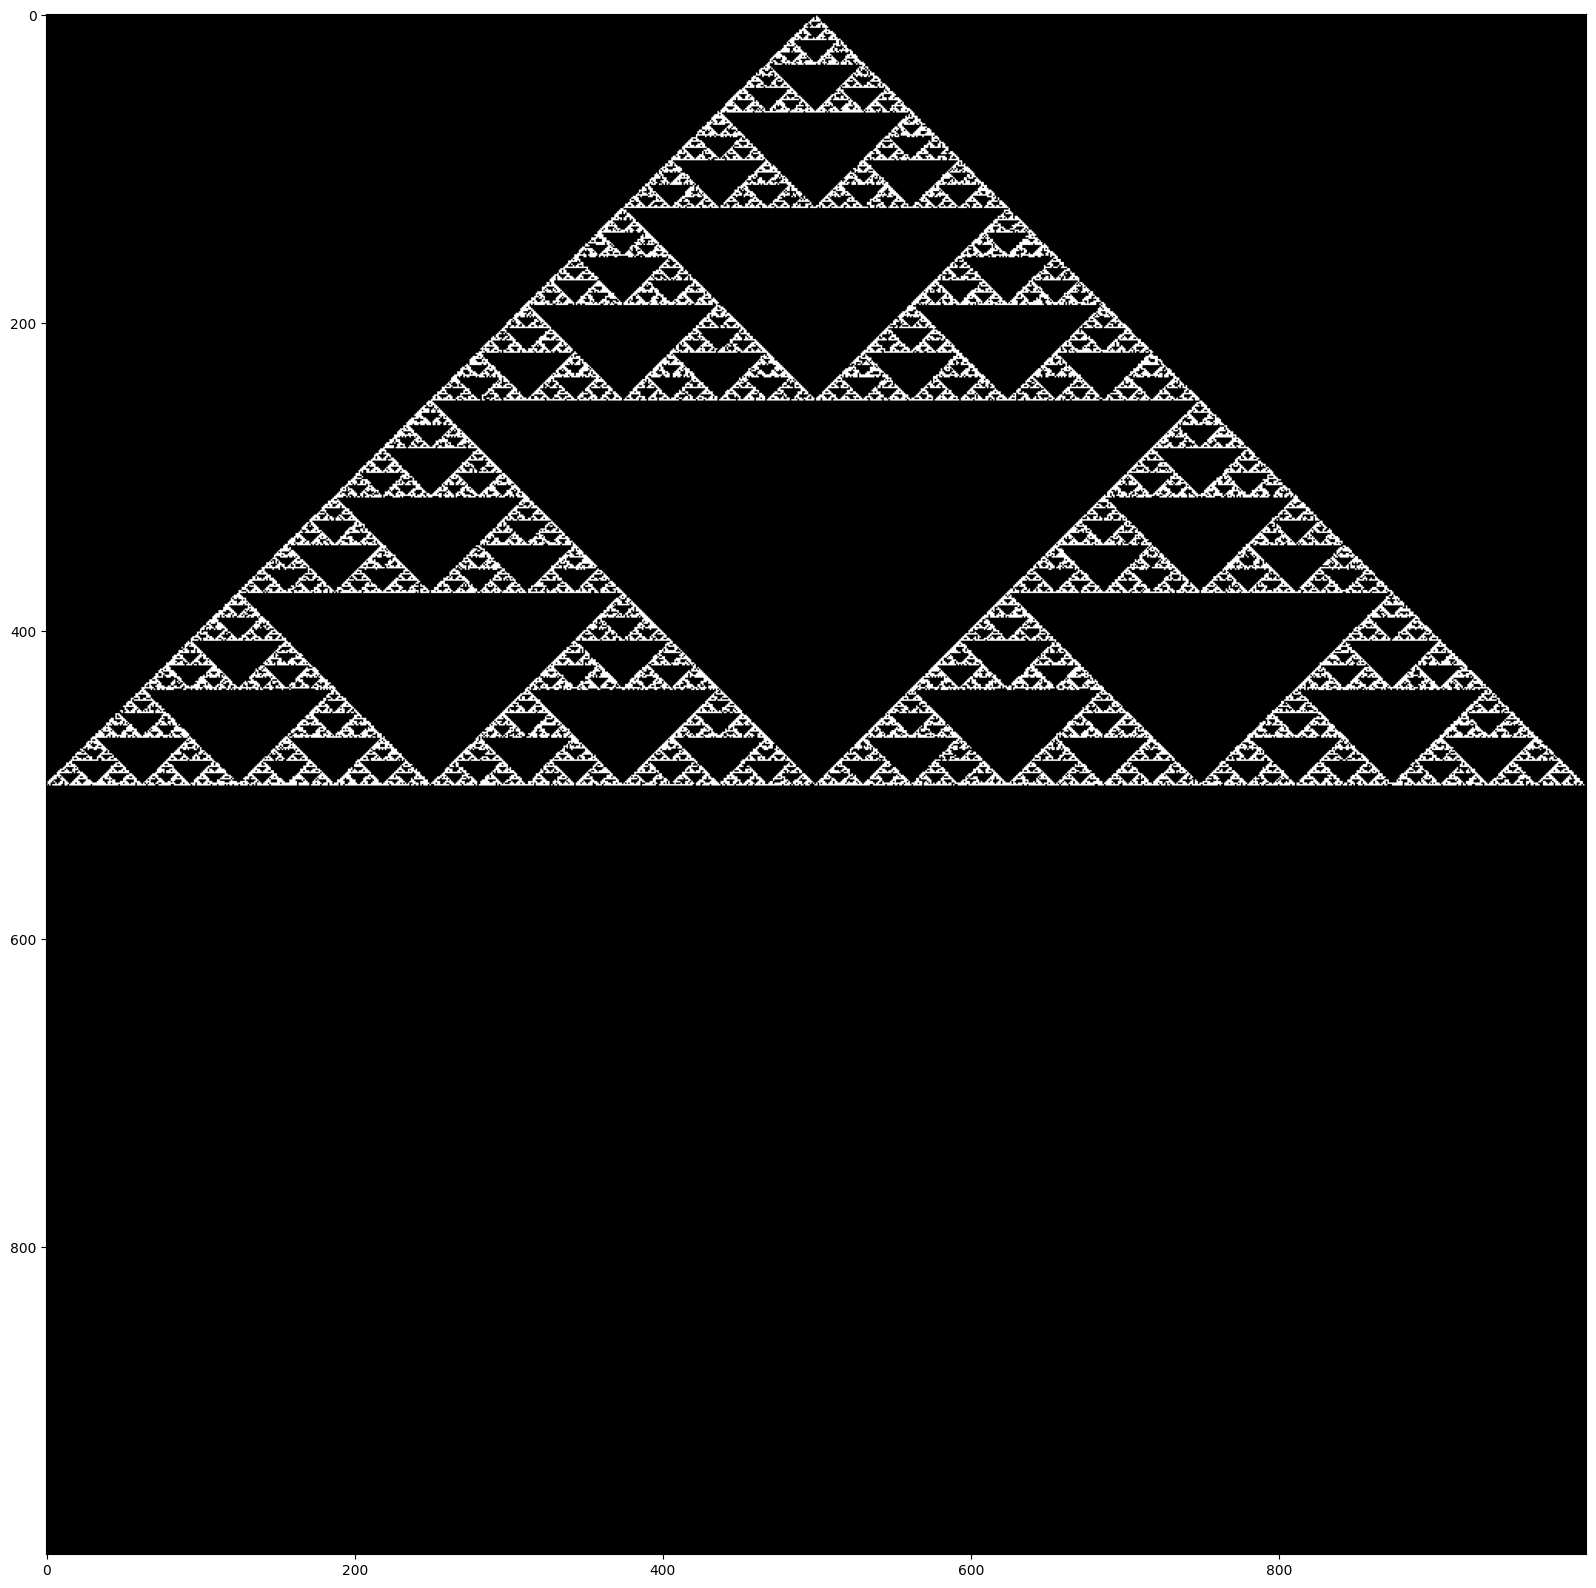

In [22]:
z = 0.5 + 0.*1j
max_iter = 100000
funcs = [
    (lambda t: shrink_rotate(t, 0. + 1.*1j, coef=0.5, angle=0.)),
    (lambda t: shrink_rotate(t, 1. + 0.*1j, coef=0.5, angle=0.)),
    (lambda t: shrink_rotate(t, -1. + 0.*1j, coef=0.5, angle=0.))
]

n = 1000
pixels = np.zeros((n, n), dtype=int)

for n_iter in range(max_iter):
    n_func = np.random.choice(len(funcs))
    z = funcs[n_func](z)
    if n_iter >= 10:
        i = int((z.imag + 1) / 2 * (n - 1))
        j = int((z.real + 1) / 2 * (n - 1))
        if 0 <= i < n and 0 <= j < n:
            pixels[n-1-i, j] = 1

plt.figure(figsize=(20, 20))
plt.imshow(pixels, cmap='gray')


**Задание 5.5 [0.75 баллов]** Попробуйте объяснить, почему получается именно эта фигура.

---
Каждая функция берет точку и двигает ее на половину пути к одной из трех фиксированных точек. Каждый раз выбирается случайная точка. В итоге они постепенно собираются в области, ограниченной теми тремя точками и получается треугольник. С каждым шагом расстояние уменьшается вдвое, поэтому трегольники попадают друг в друга и получается красивый график.

**Задание 5.6 [0.5 баллов]** Поэкспериментируйте с другими преобразованиями. Попробуйте найти какой-нибудь другой красиво выглядящий фрактал.

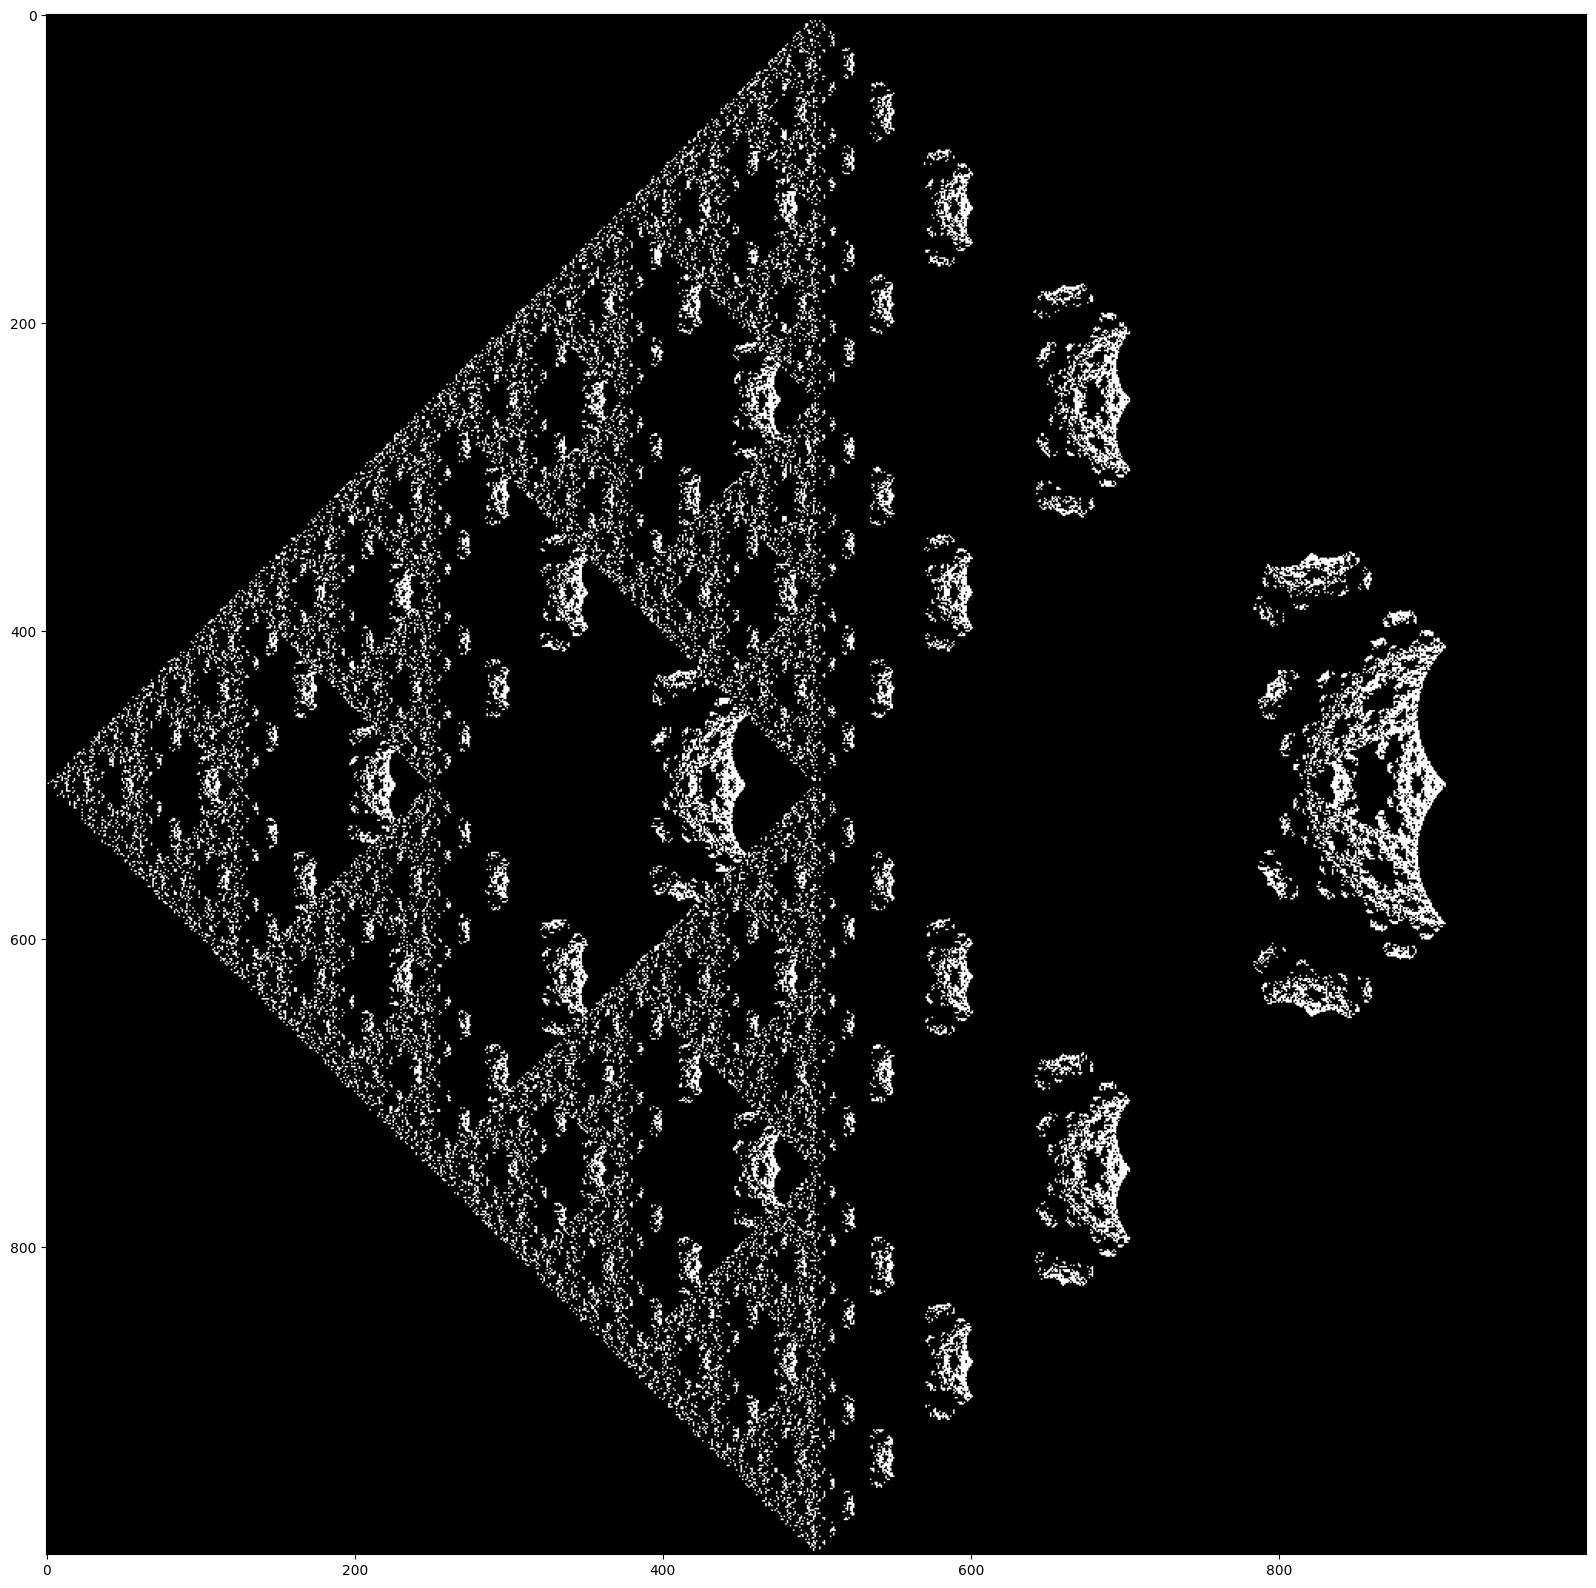

In [23]:
z = 0.5 + 0.*1j
max_iter = 100000
funcs = [
    lambda t: shrink_rotate(t, 0+1j,   coef=0.5, angle=0.0),
    lambda t: geometric_inverse(t, 1+0j, r=0.6),
    lambda t: shrink_rotate(t, -1+0j,  coef=0.5, angle=0.0),
    lambda t: shrink_rotate(t, 0-1j,   coef=0.5, angle=0.0)
]

n = 1000
pixels = np.zeros((n, n), dtype=int)

for n_iter in range(max_iter):
    n_func = np.random.choice(len(funcs))
    z = funcs[n_func](z)
    if n_iter >= 10:
        i = int((z.imag + 1) / 2 * (n - 1))
        j = int((z.real + 1) / 2 * (n - 1))
        if 0 <= i < n and 0 <= j < n:
            pixels[n-1-i, j] = 1


plt.figure(figsize=(20, 20))
plt.imshow(pixels, cmap='gray')


# Вот это вообще хайп, как какие-то кратеры получается узор


## Часть 6 (бонус). Метод Гаусса или обратные матрицы?

**Задание 6.1 [1.5 балла]** Пусть нам дано матричное уравнение $Ax = B$, где $A$ – матрица размера $n\times n$, а $B$ – матрица размера $n\times m$ (отметим, что это уравнение можно интерпретировать как $m$ систем с векторными правыми частями и однаковыми левыми). Вообще говоря, методов решения таких уравнений очень много, но мы пока рассмотрим два из них, с которыми вы уже хорошо знакомы.
1. Метод Гаусса;
2. Умножение на обратную матрицу: $x = A^{-1}B$.

В этом задании вы попробуете ответить на вопрос о том, какой из этих методов эффективнее. Проведите два эксперимента:
- сравните скорости решения системы при фиксированном `m = 10` и `n`, изменяющемся в пределах от 10 до 1000, например, для `n=10, 50, 100, 200, 500, 1000` (рост числа неизвестных при фиксированном количестве правых частей);
- сравните скорости решения системы при фиксированном `n = 100` и `m`, меняющемся от 10 до 10000, например, для `m = 10, 100, 500, 1000, 2000, 5000, 10000` (рост числа правых частей при фиксированном числе неизвестных).

При проведении экспериментов не возбраняется использовать циклы `for`.

Эксперименты проведите на случайных матрицах, созданных с помощью функции `numpy.random.rand`. Постройте графики времени выполнения функции от размерности (лучше в логарифмическом масштабе). Сделайте выводы (в письменном виде!) о том, какой из методов оказывается лучше в каких обстоятельствах.

Чтобы всё это не казалось вам чёрной магией, найдите число операций (суммарно сложения, умножения и деления), необходимых для решения системы каждым из методов. Обратите внимание на члены суммарной степени 3 (суммарной по $m$ и $n$; члены меньшего порядка можете даже не считать). Постарайтесь объяснить полученные ранее результаты.

----
Для начала по честному напишем свою функцию решения методом Гаусса и посмотрим на результаты:

/var/folders/cm/8d_gw3h92hs5ybt5ctbvk3w80000gn/T/ipykernel_71539/2325016526.py:20: RuntimeWarning: divide by zero encountered in matmul
  X = A_inversed @ B
/var/folders/cm/8d_gw3h92hs5ybt5ctbvk3w80000gn/T/ipykernel_71539/2325016526.py:20: RuntimeWarning: overflow encountered in matmul
  X = A_inversed @ B
/var/folders/cm/8d_gw3h92hs5ybt5ctbvk3w80000gn/T/ipykernel_71539/2325016526.py:20: RuntimeWarning: invalid value encountered in matmul
  X = A_inversed @ B


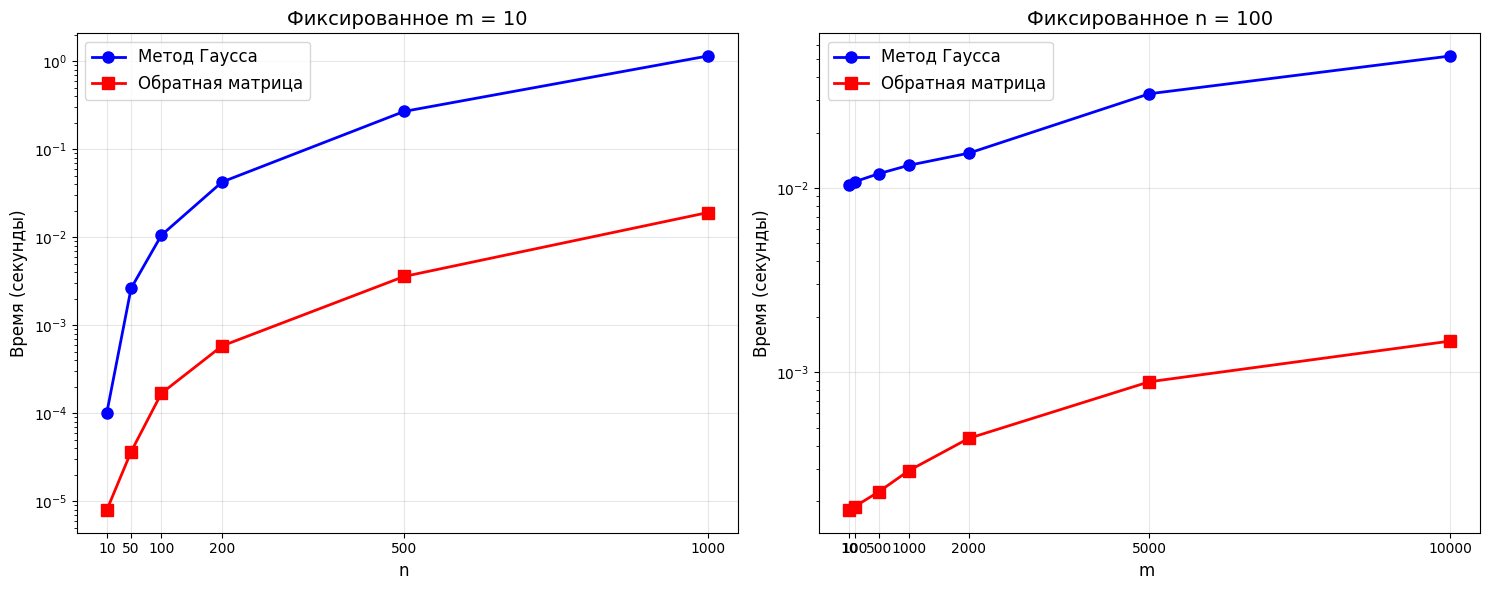

In [26]:
def gauss(A, B):
    n, m = B.shape
    for i in range(n):
        pivot = A[i, i]
        for j in range(i+1, n):
            f = A[j, i] / pivot
            A[j, i:] -= f * A[i, i:]
            B[j, :] -= f * B[i, :]
    X = np.zeros((n, m))
    for i in range(n-1, -1, -1):
        X[i, :] = B[i, :]
        for j in range(i+1, n):
            X[i, :] -= A[i, j] * X[j, :]
        X[i, :] /= A[i, i]
    return X


def inverse(A, B):
    A_inversed = sla.inv(A)
    X = A_inversed @ B
    return X


m = 10
n_val = [10, 50, 100, 200, 500, 1000]
gauss_times1 = []
inv_times1 = []
gauss_times2 = []
inv_times2 = []

for n in n_val:
    A = np.random.rand(n, n)
    B = np.random.rand(n, m)

    A_copy = A.copy()
    B_copy = B.copy()

    res_gauss = %timeit -o -q gauss(A_copy, B_copy)
    gauss_times1.append(res_gauss.best)

    res_inv = %timeit -o -q inverse(A, B)
    inv_times1.append(res_inv.best)

m_val = [10, 100, 500, 1000, 2000, 5000, 10000]
n = 100

for m in m_val:
    A = np.random.rand(n, n)
    B = np.random.rand(n, m)

    A_copy = A.copy()
    B_copy = B.copy()

    res_gauss = %timeit -o -q gauss(A_copy, B_copy)
    gauss_times2.append(res_gauss.best)

    res_inv = %timeit -o -q inverse(A, B)
    inv_times2.append(res_inv.best)

plt.figure(figsize=(15, 6))


plt.subplot(1, 2, 1)
plt.semilogy(n_val, gauss_times1, color='blue', label='Метод Гаусса', marker='o', linewidth=2, markersize=8)
plt.semilogy(n_val, inv_times1, color='red', label='Обратная матрица', marker='s', linewidth=2, markersize=8)
plt.xlabel('n ', fontsize=12)
plt.ylabel('Время (секунды)', fontsize=12)
plt.title('Фиксированное m = 10', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(n_val)

plt.subplot(1, 2, 2)
plt.semilogy(m_val, gauss_times2, color='blue', label='Метод Гаусса', marker='o', linewidth=2, markersize=8)
plt.semilogy(m_val, inv_times2, color='red', label='Обратная матрица', marker='s', linewidth=2, markersize=8)
plt.xlabel('m ', fontsize=12)
plt.ylabel('Время (секунды)', fontsize=12)
plt.title('Фиксированное n = 100', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(m_val)

plt.tight_layout()
plt.show()



Если что, ошибки возникают из-за того что рандомная матрица может быть вырожденной и не получается взять обратную от нее.

Как мы видим на графика, метод Гаусса значительно медленне, чем обртаная матрица, в обоих случаях. Однако это можно списать на неоптимизированность рукописного кода (ведь решение обратной матрицей использует библиотечную функцию, а Гаусс нет). Поэтому ниже протестируем в равных условиях, где оба метода будут реализованы библиотечными функциями.

/var/folders/cm/8d_gw3h92hs5ybt5ctbvk3w80000gn/T/ipykernel_71539/3923848406.py:8: RuntimeWarning: divide by zero encountered in matmul
  X = A_inversed @ B
/var/folders/cm/8d_gw3h92hs5ybt5ctbvk3w80000gn/T/ipykernel_71539/3923848406.py:8: RuntimeWarning: overflow encountered in matmul
  X = A_inversed @ B
/var/folders/cm/8d_gw3h92hs5ybt5ctbvk3w80000gn/T/ipykernel_71539/3923848406.py:8: RuntimeWarning: invalid value encountered in matmul
  X = A_inversed @ B


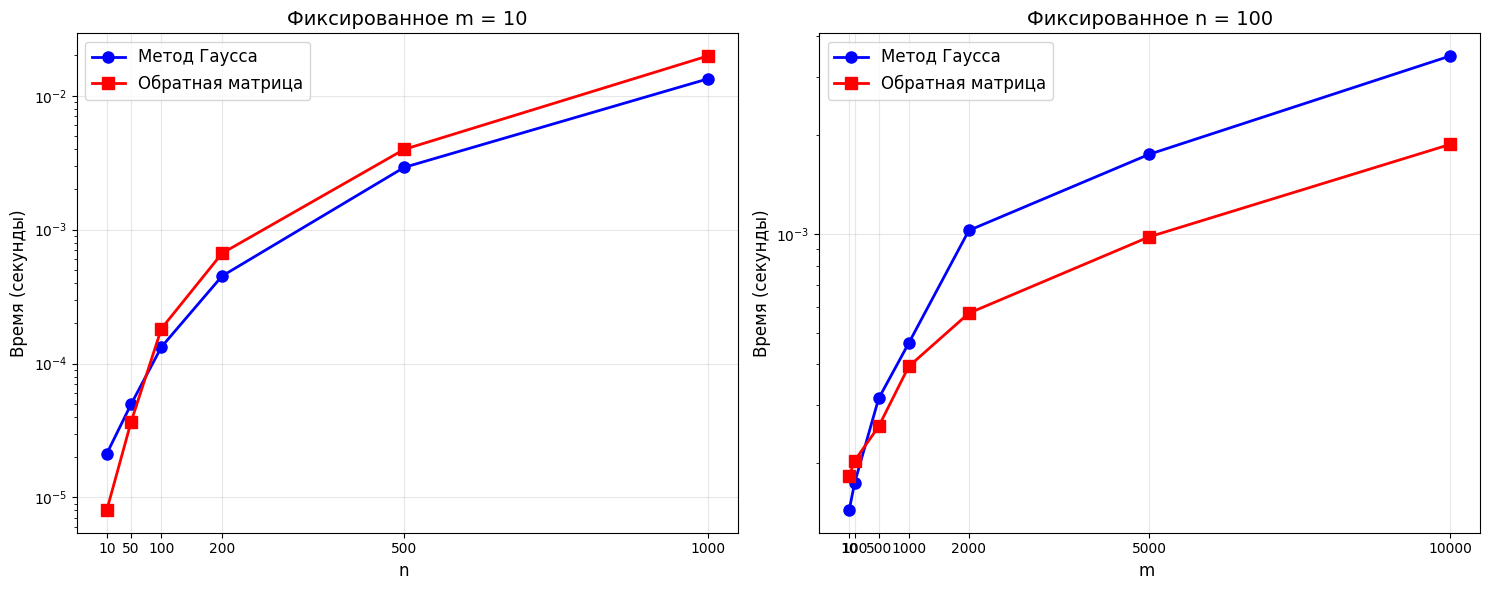

In [27]:
def gauss(A, B):
    X = sla.solve(A, B)
    return X


def inverse(A, B):
    A_inversed = sla.inv(A)
    X = A_inversed @ B
    return X


m = 10
n_val = [10, 50, 100, 200, 500, 1000]
gauss_times1 = []
inv_times1 = []
gauss_times2 = []
inv_times2 = []

for n in n_val:
    A = np.random.rand(n, n)
    B = np.random.rand(n, m)

    A_copy = A.copy()
    B_copy = B.copy()

    res_gauss = %timeit -o -q gauss(A_copy, B_copy)
    gauss_times1.append(res_gauss.best)

    res_inv = %timeit -o -q inverse(A, B)
    inv_times1.append(res_inv.best)

m_val = [10, 100, 500, 1000, 2000, 5000, 10000]
n = 100

for m in m_val:
    A = np.random.rand(n, n)
    B = np.random.rand(n, m)

    A_copy = A.copy()
    B_copy = B.copy()

    res_gauss = %timeit -o -q gauss(A_copy, B_copy)
    gauss_times2.append(res_gauss.best)

    res_inv = %timeit -o -q inverse(A, B)
    inv_times2.append(res_inv.best)

plt.figure(figsize=(15, 6))


plt.subplot(1, 2, 1)
plt.semilogy(n_val, gauss_times1, color='blue', label='Метод Гаусса', marker='o', linewidth=2, markersize=8)
plt.semilogy(n_val, inv_times1, color='red', label='Обратная матрица', marker='s', linewidth=2, markersize=8)
plt.xlabel('n ', fontsize=12)
plt.ylabel('Время (секунды)', fontsize=12)
plt.title('Фиксированное m = 10', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(n_val)

plt.subplot(1, 2, 2)
plt.semilogy(m_val, gauss_times2, color='blue', label='Метод Гаусса', marker='o', linewidth=2, markersize=8)
plt.semilogy(m_val, inv_times2, color='red', label='Обратная матрица', marker='s', linewidth=2, markersize=8)
plt.xlabel('m ', fontsize=12)
plt.ylabel('Время (секунды)', fontsize=12)
plt.title('Фиксированное n = 100', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(m_val)

plt.tight_layout()
plt.show()


Видим, что ситуация стала интереснее, теперь скорость решений не так сильно отличается. Для фиксированного m, в начале, при маленьких значениях, метод обратной матрицы работает быстрее, но далее метод Гаусса опережает. Для фиксированного n имеем обратную ситуацию. 

Для первого графика:

При маленьких n функции, которые считают обратную матрицу работают очень быстро, и сильно выигрывают у Гаусса, однако при больших n вычисления обратной матрицы становятся гораздо сложнее чем решение системы, отсюда и результат.

Для второго графика:

Заметим, что Гаусс фактически считает систему m раз, один столбец за другим, отсбда линейный рост времени. В то время как обратная матрица считает сложную инверсию только 1 раз, а потом быстрое умножение. Отсюда получаем, что при росте m метод Гаусса начинает проигрывать.